# Investigate Transect 

This notebook plots seasonal mean and daily mean sections (using pyfesom) across Fram Strait along with TS Diagrams to formulate model specific water mass definitions.

## Imports

In [1]:
import pyfesom as pf
import numpy as np
import gsw
import xarray as xr
from tqdm import tqdm

# Plotting
import matplotlib.pyplot as plt
import cmocean as cmo

# Custom
import sys
sys.path.append("./functions")
import functions.ocean_helper as ochlp
import functions.FESOM_processing as fepc

%load_ext autoreload
%autoreload 2

/albedo/home/quraus001/pyfesom/pyfesom/climatology.py:21: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
# Load FESOM mesh
meshpath = '/albedo/home/quraus001/Arc08_sub/'
mesh = pf.load_mesh(meshpath, usepickle=True)

# Load model output
ocefile_mean = "/albedo/work/user/quraus001/FESOM_particles/result/processed_results/Arc40_2006-2007_oce_yseasmean.nc"
ocefile  = "/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/Arc40.2006.oce.mean.sub.nc"

ds_mean = fepc.load_FESOM_data_with_grid(meshpath, ocefile_mean)
ds = fepc.load_FESOM_data_with_grid(meshpath, ocefile)
snap_days = [14, 104, 195, 287] # Jan 15, Aprl 15, Jul 15, Oct 15
ds = ds.isel(time=snap_days).copy()

/albedo/home/quraus001/Arc08_sub/pickle_mesh_py3
3
The usepickle == True)
The pickle file for python 3 exists.
The mesh will be loaded from /albedo/home/quraus001/Arc08_sub/pickle_mesh_py3


## Extract Data from unstructured mesh

In [3]:
kwargs = {"mesh"      : mesh, 
          "lon_start" : -12, 
          "lat_start" : 78, 
          "lon_end"   : 12 , 
          "lat_end"   : 78, 
          "npoints"   : 300, 
          "maxdepth"  : 1000, 
          "label"     : '$^{\\circ}$C', 
          "levels"    : None, 
          "ncols"     : 1,
          "return_data" : True,}

In [4]:
def convert_to_teos10(transect_data_T, transect_data_S, transect_depth, transect_lon, transect_lat):
    """
    Convert in-situ temperature + practical salinity to
    Conservative Temperature and Absolute Salinity (TEOS-10).
    
    Parameters
    ----------
    transect_data_T : np.ndarray  (depth x along-track)
    transect_data_S : np.ndarray  (depth x along-track)
    transect_depth  : np.ndarray  (depth,)          — positive metres
    transect_lon    : np.ndarray  (along-track,)
    transect_lat    : np.ndarray  (along-track,)
    
    Returns
    -------
    SA : np.ndarray   Absolute Salinity      (g/kg)
    CT : np.ndarray   Conservative Temperature (°C)
    """
    # Broadcast depth, lon, lat to (depth x along-track) shape
    depth_2d = transect_depth[:, np.newaxis] * np.ones_like(transect_data_S)
    lon_2d   = np.ones((transect_data_S.shape[0], 1)) * transect_lon[np.newaxis, :]
    lat_2d   = np.ones((transect_data_S.shape[0], 1)) * transect_lat[np.newaxis, :]

    # Depth (m) → pressure (dbar); gsw wants pressure, not depth
    pressure = gsw.p_from_z(depth_2d, lat_2d)   # z must be negative (below surface)

    SA = gsw.SA_from_SP(transect_data_S, pressure, lon_2d, lat_2d)
    CT = gsw.CT_from_pt(SA, transect_data_T)

    return SA, CT

In [5]:
from matplotlib.gridspec import GridSpec

# Define seasons with their approximate middle day (day of year)
season_middle_doy = {
    "winter": 15,    # ~Jan 15 (or adjust to your time axis)
    "spring": 105,   # ~Apr 15
    "summer": 196,   # ~Jul 15
    "autumn": 288,   # ~Oct 15
}

def extract_data(ds_sel, Transect_data_season, kwargs):
    """Builds one figure (mean or snapshot) and returns it."""

    with plt.ioff():
        kwargs.update({"data3d": ds_sel.temp.values, "label": "Temperature (°C)", "cmap": cmo.cm.thermal, "levels":np.arange(-2,6.5,0.5)})
        _, transect_data_T = pf.plot_transect(**kwargs)
        Transect_data_season["T"] = transect_data_T

        kwargs.update({"data3d": ds_sel.salt.values, "label": "Salinity (PSU)", "cmap": cmo.cm.haline, "levels":np.arange(31.2,35,0.2)})
        _, transect_data_S = pf.plot_transect(**kwargs)
        Transect_data_season["S"] = transect_data_S

    # Reconstruct transect coordinates from kwargs

    # 1. Along-track lon/lat: linearly interpolate between start and end
    transect_lon = np.linspace(kwargs["lon_start"], kwargs["lon_end"], kwargs["npoints"])
    transect_lat = np.linspace(kwargs["lat_start"], kwargs["lat_end"], kwargs["npoints"])

    # 2. Depth levels: all levels from the dataset down to maxdepth
    all_depths    = ds.depth_levels.values                          # full 1-D array, metres
    depth_mask    = all_depths >= (kwargs["maxdepth"] *-1)
    transect_depth = all_depths[depth_mask]                         # trimmed to maxdepth

    # Convert to absolute salinity and conservative temperature
    SA, CT = convert_to_teos10(
        transect_data_T, transect_data_S,
        transect_depth, transect_lon, transect_lat
    )

    Transect_data_season["SA"] = SA
    Transect_data_season["CT"] = CT

    return 


Transect_data = {}
for s, season in enumerate(["winter", "spring", "summer", "autumn"][:]):
    print(season)
    Transect_data[season] = {}

    # Seasonal mean from ds_mean 
    Transect_data[season]["mean"] = {}
    fig_mean = extract_data(
        ds_mean.isel(time=s),
        Transect_data_season=Transect_data[season]["mean"],
        kwargs=kwargs.copy()
    )

    # Daily snapshot from ds at season midpoint 
    Transect_data[season]["snapshot"] = {}
    fig_snap = extract_data(
        ds.isel(time=s),
        Transect_data_season=Transect_data[season]["snapshot"],
        kwargs=kwargs.copy()
    )

plt.close()

# might still give back a weird plot but don't worry about that, we'll do nice(er) plots in the next cell

winter
spring
summer
autumn


## Plotting Sections & TS Diagram

winter


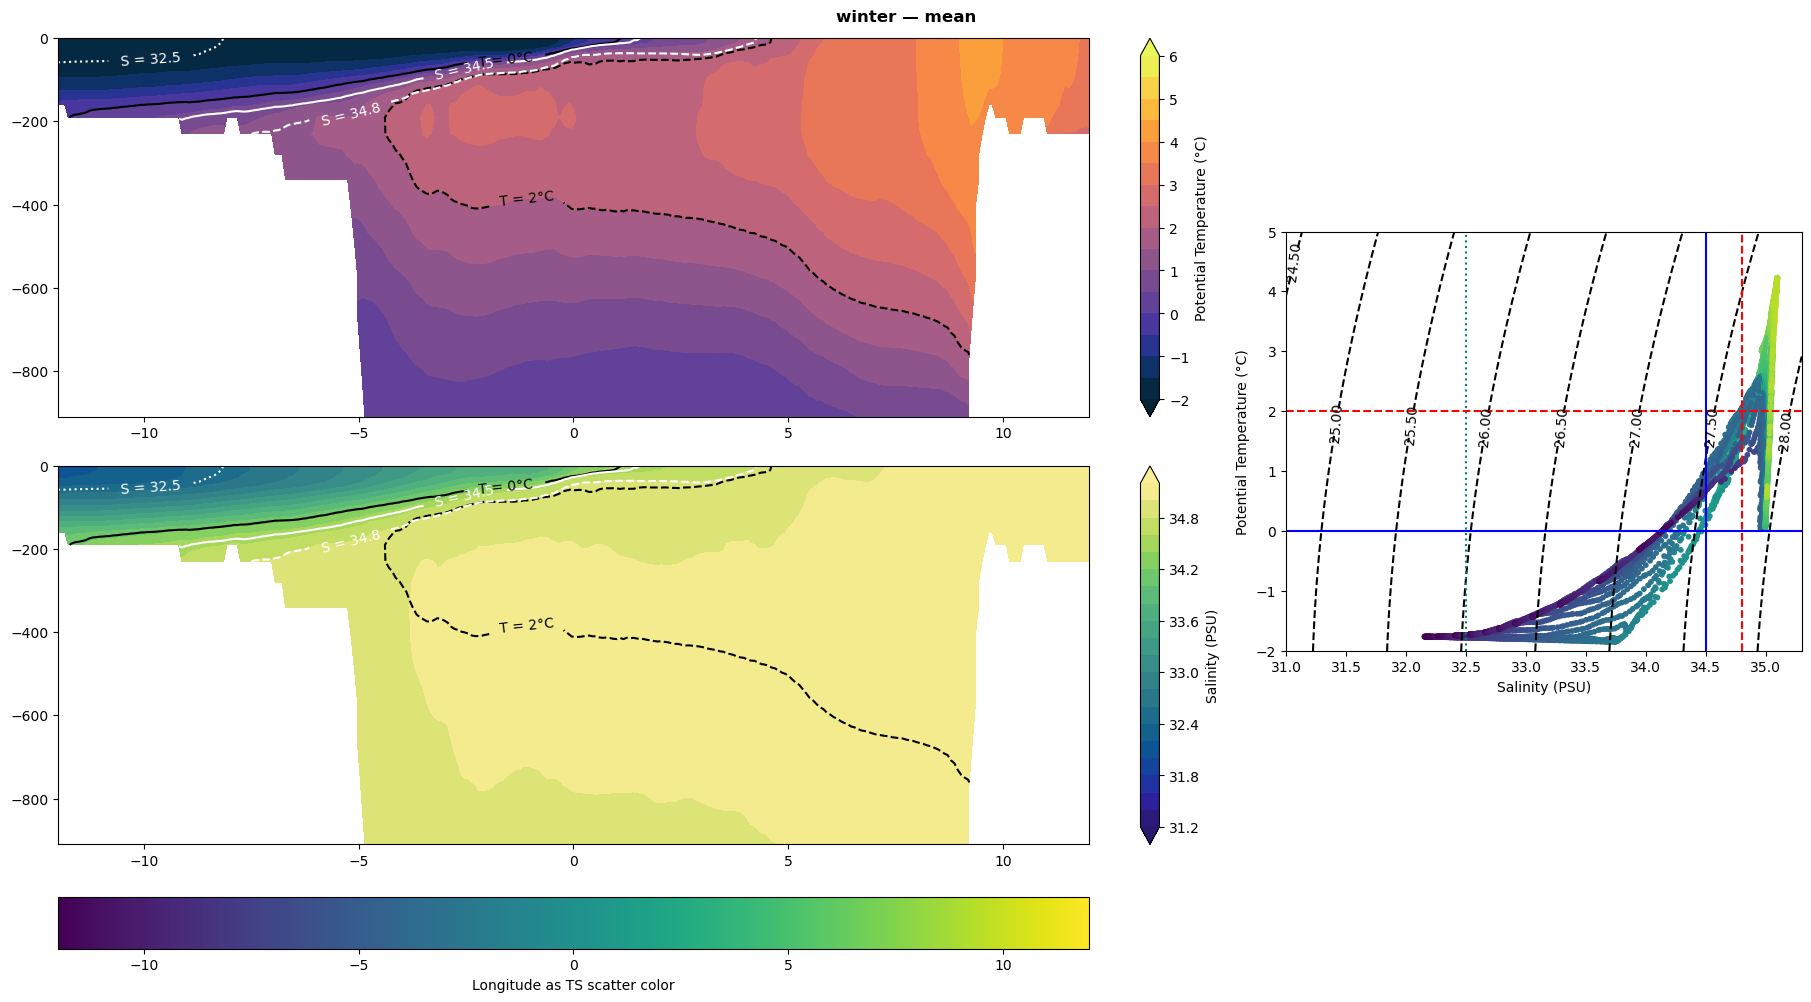

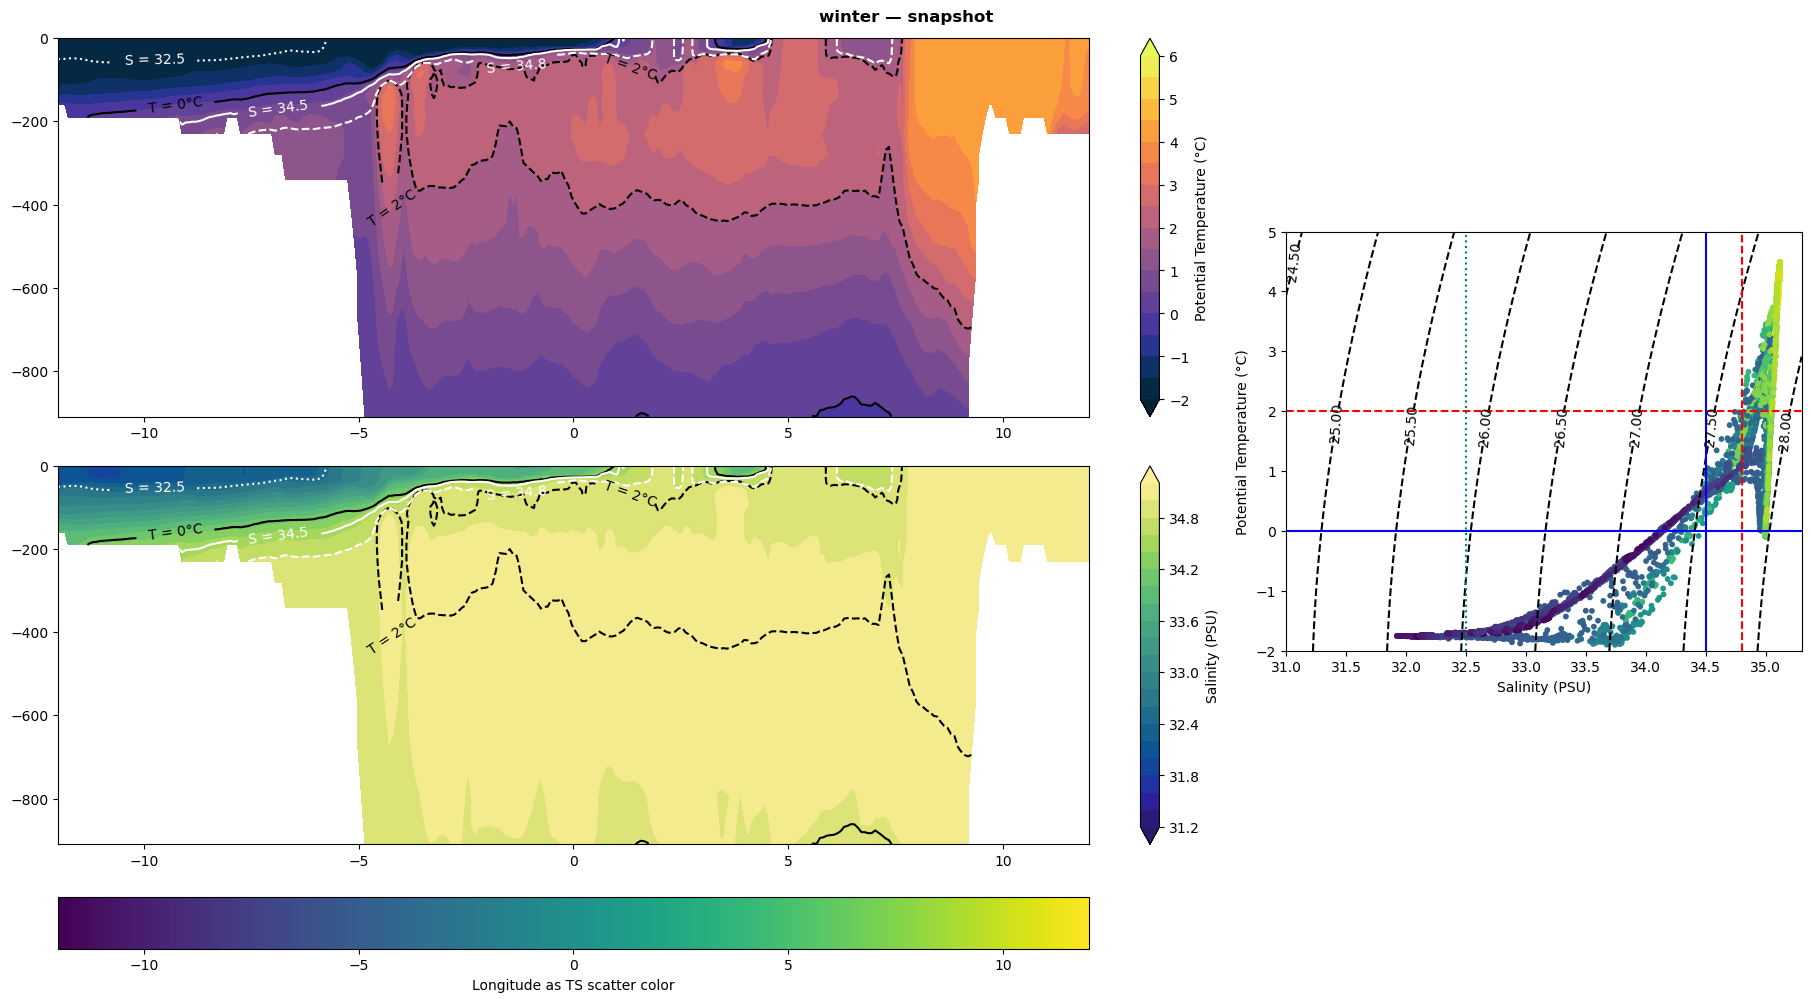

spring


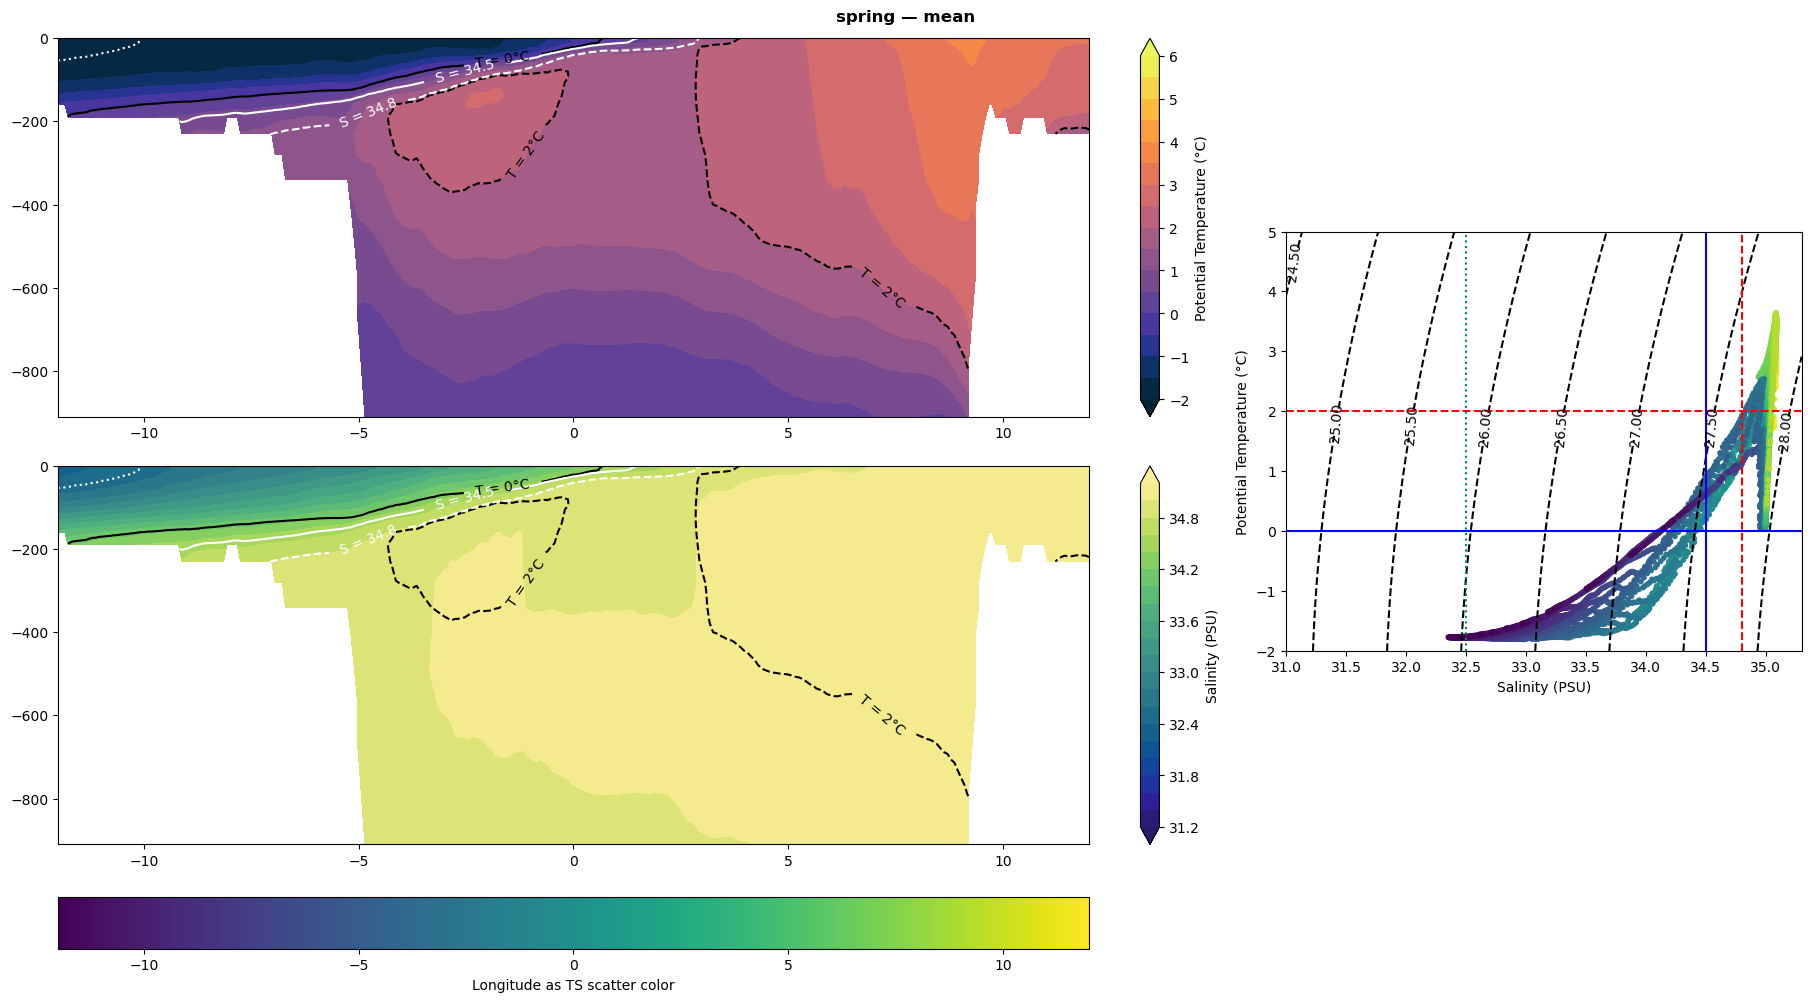

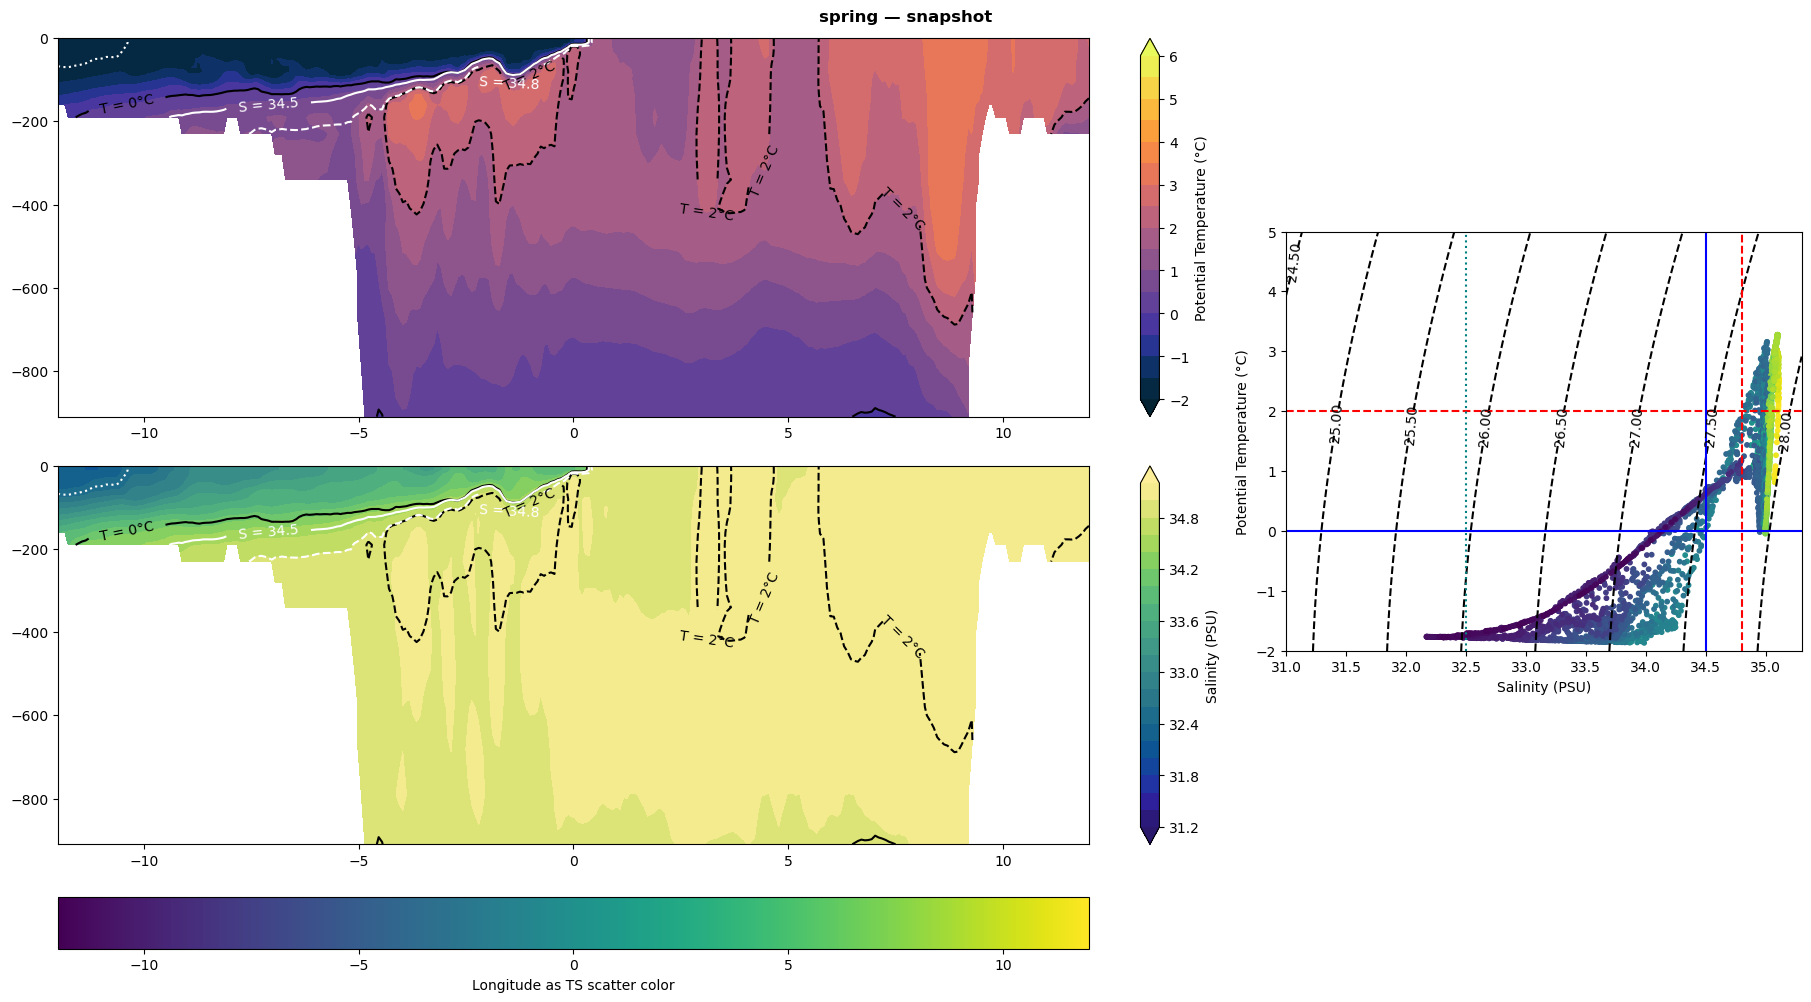

summer


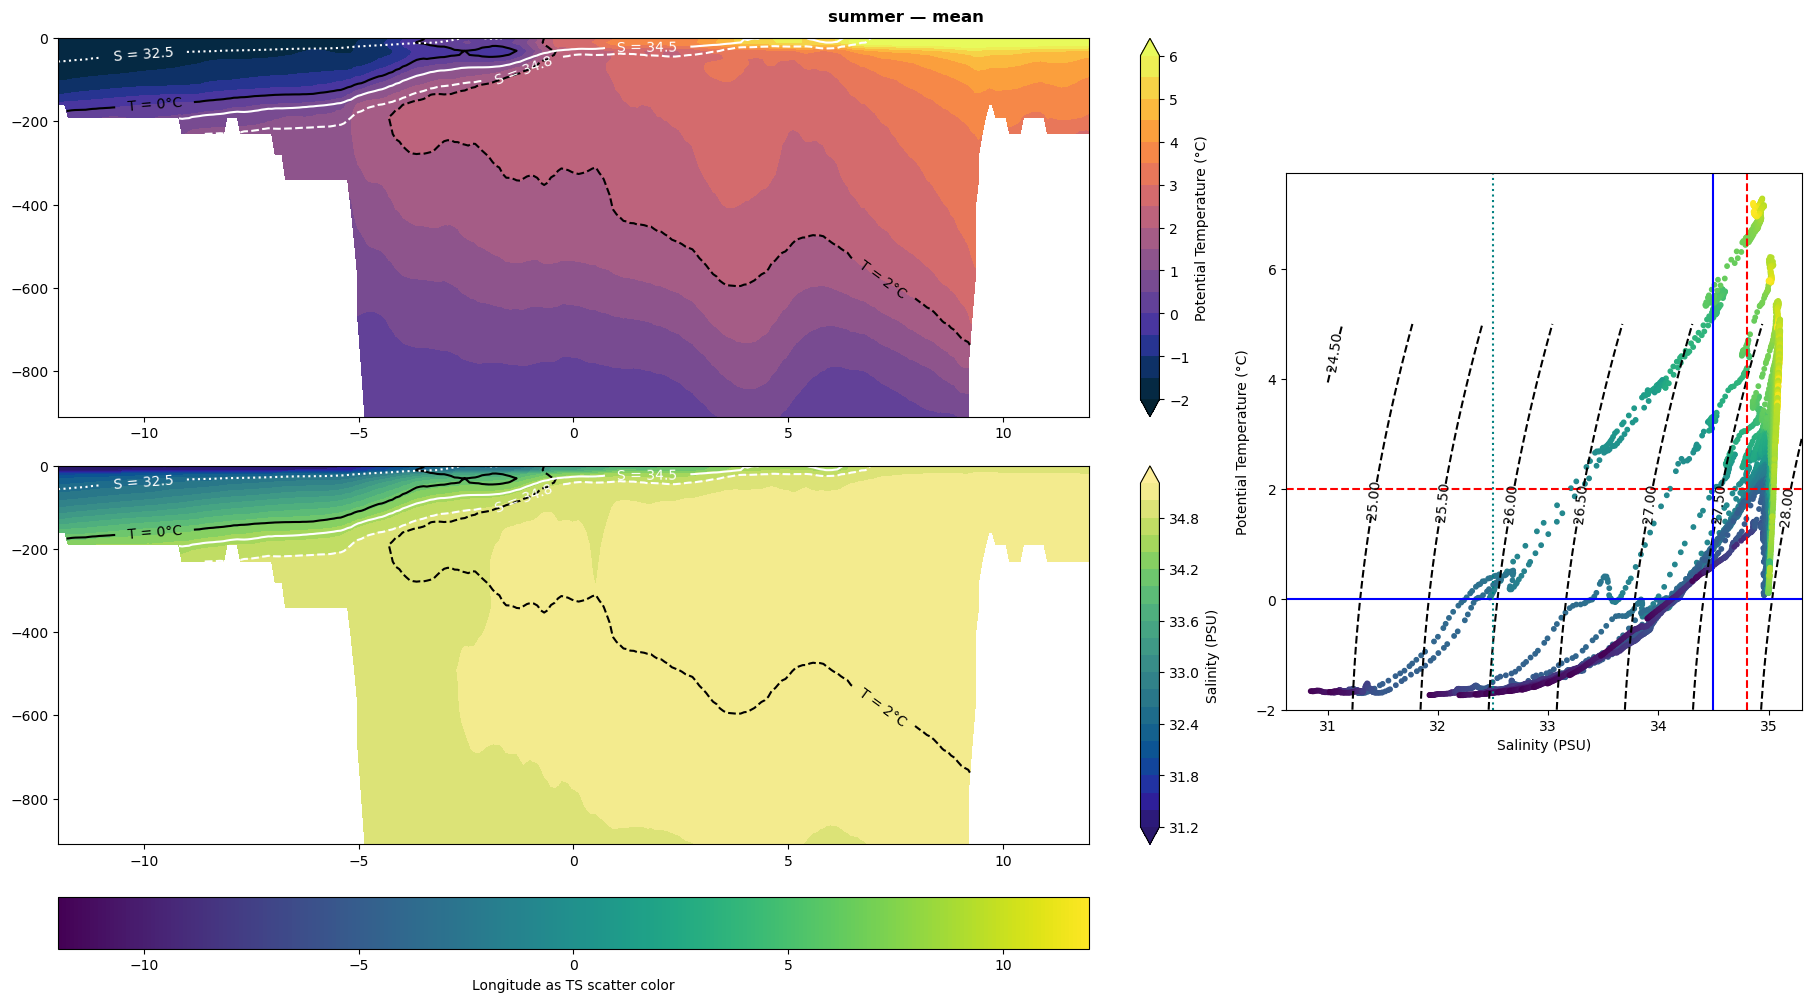

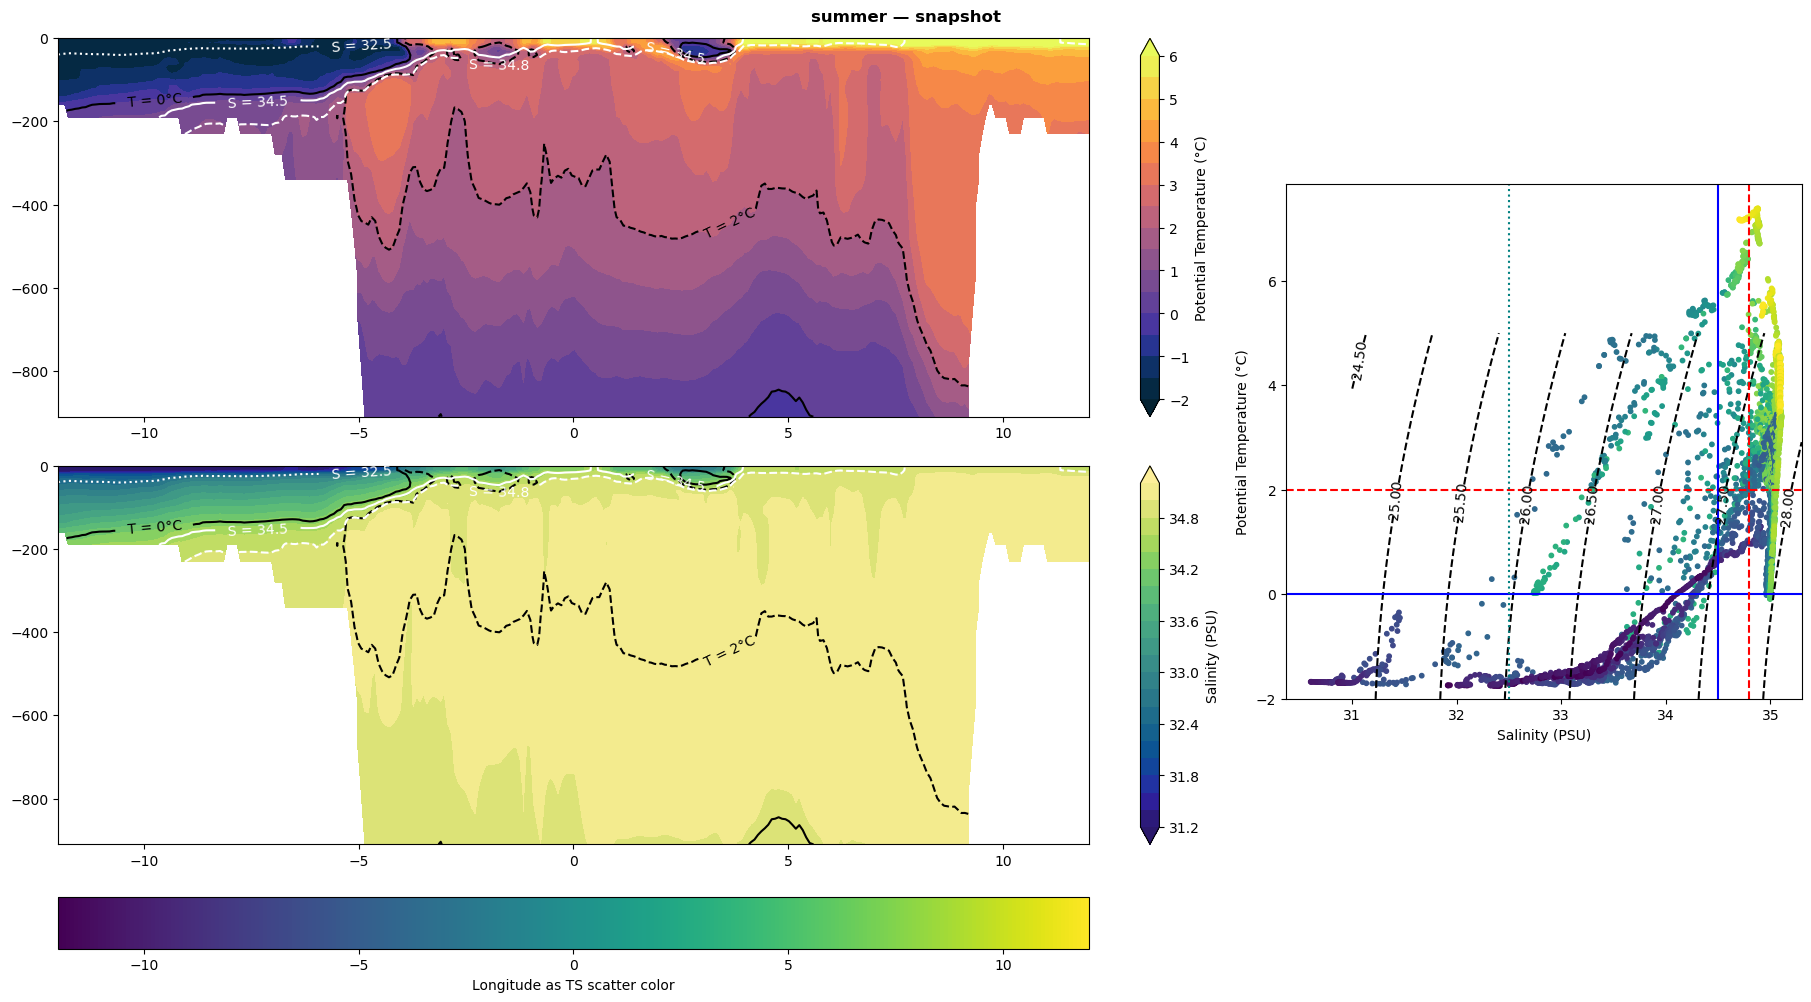

autumn


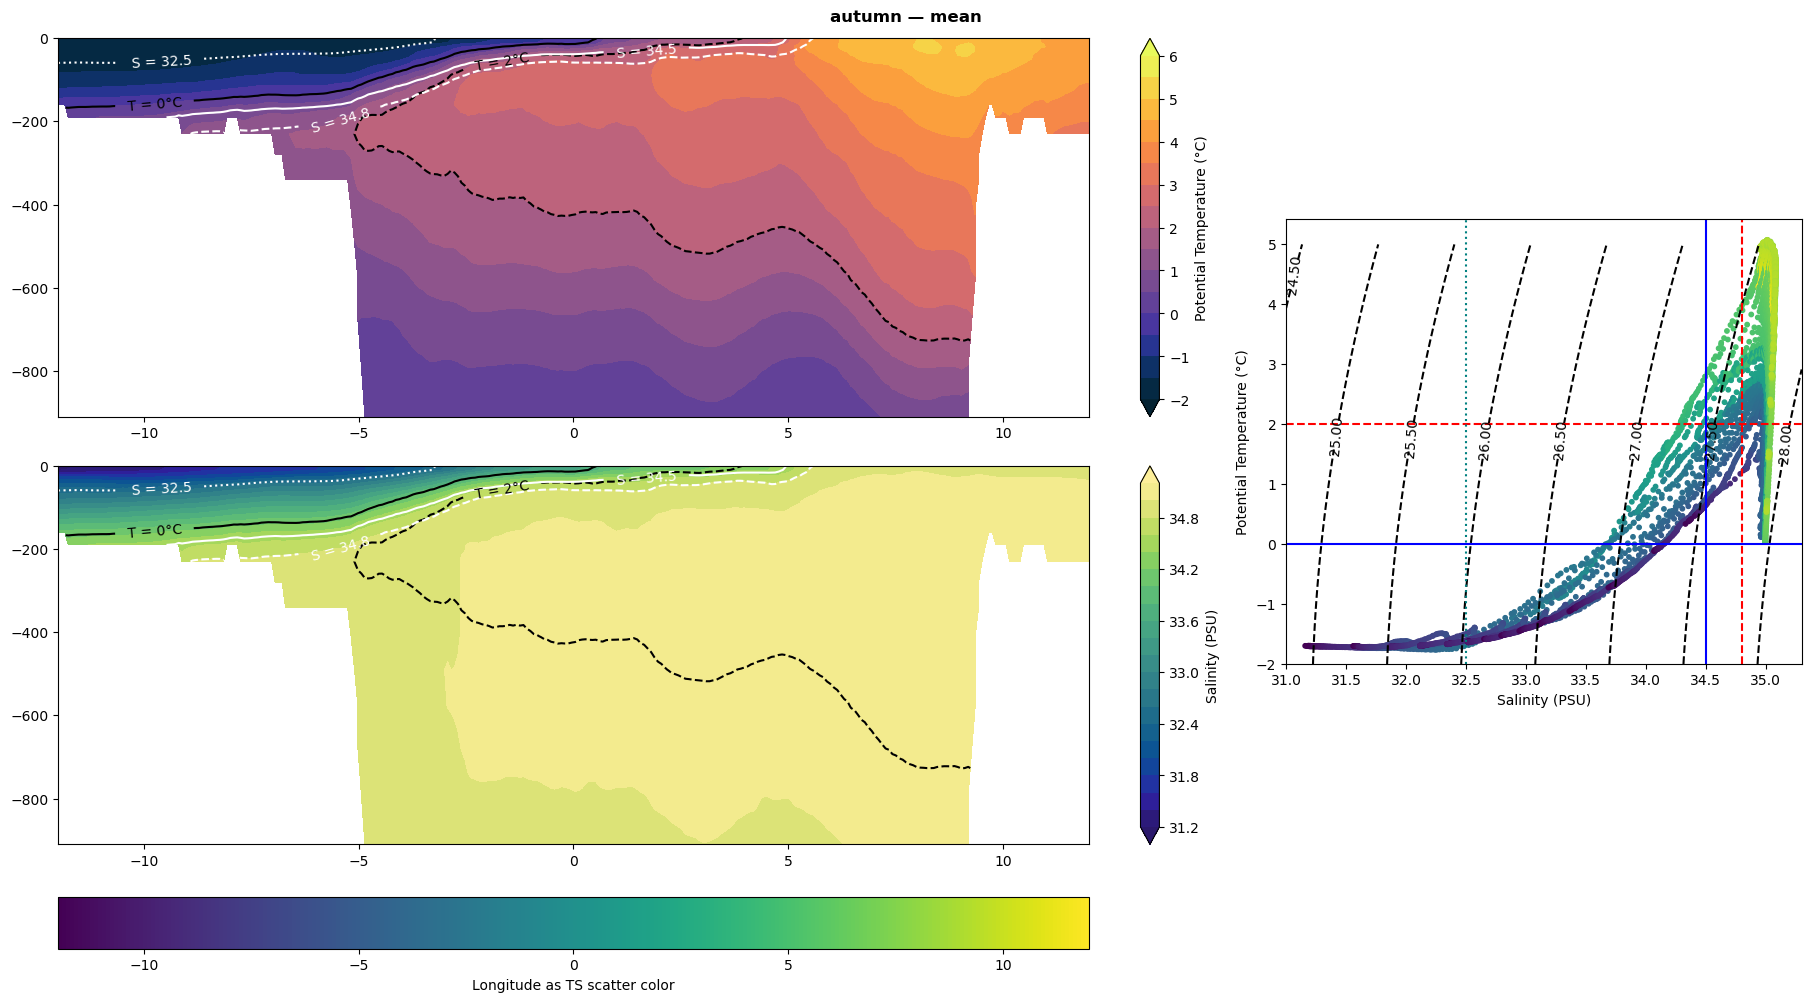

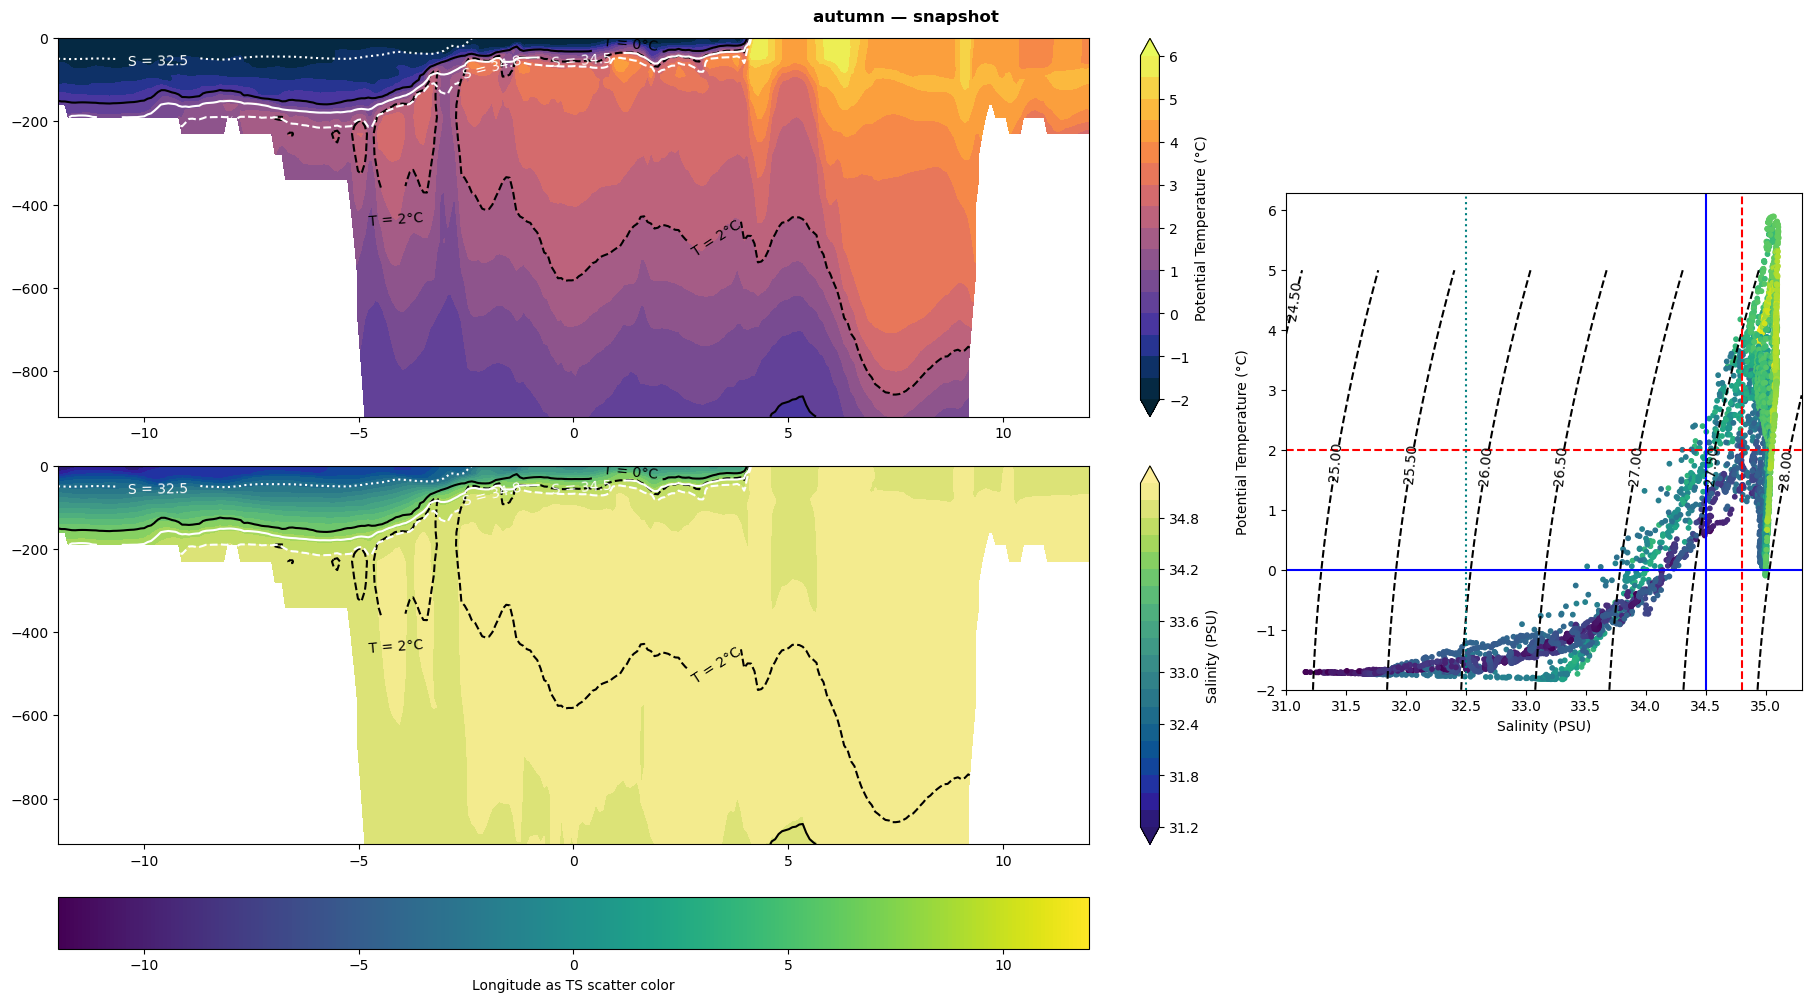

In [6]:
variables = "model" 

all_depths    = ds.depth_levels.values                          # full 1-D array, metres
depth_mask    = all_depths >= (kwargs["maxdepth"] *-1)
transect_depth = all_depths[depth_mask]                         # trimmed to maxdepth

# 1. Along-track lon/lat: linearly interpolate between start and end
transect_lon = np.linspace(kwargs["lon_start"], kwargs["lon_end"], kwargs["npoints"])
transect_lat = np.linspace(kwargs["lat_start"], kwargs["lat_end"], kwargs["npoints"])

for s, season in enumerate(["winter", "spring", "summer", "autumn"][:]):
    print(season)
    for period in ["mean", "snapshot"]:

        fig = plt.figure(figsize=(18, 10), constrained_layout=True)
        gs = GridSpec(
            nrows=2, ncols=2,
            width_ratios=[2, 1],
            height_ratios=[1, 1],
            figure=fig
        )
        ax1     = fig.add_subplot(gs[0, 0])
        ax2     = fig.add_subplot(gs[1, 0], sharex=ax1)
        ax_right = fig.add_subplot(gs[:, 1])

        if variables == "model":
            T = Transect_data[season][period]["T"]#.data
            S = Transect_data[season][period]["S"]#.data
            T_label = "Potential Temperature (°C)"
            S_label = "Salinity (PSU)"
        else:
            S = Transect_data[season][period]["SA"]#.data
            T = Transect_data[season][period]["CT"]#.data
            T_label = "Conservative Temperature (°C)"
            S_label = "Absolute Salinity (1)"
        

        im1 = ax1.contourf(transect_lon, transect_depth, T, cmap=cmo.cm.thermal, levels=np.arange(-2,6.5,0.5), extend="both")
        im2 = ax2.contourf(transect_lon, transect_depth, S, cmap=cmo.cm.haline, levels=np.arange(31.2,35.2,0.2), extend="both")
        for ax in [ax1, ax2]:
            CS_T = ax.contour(transect_lon, transect_depth, T, levels=[0, 2], colors=["black","black"], linestyles=["-","--"])#["T=0", "T=2"]
            CS_S = ax.contour(transect_lon, transect_depth, S, levels=[32.5, 34.5, 34.8], colors=["w","w","w"], linestyles=[":","-","--"])
            ax.clabel(CS_T, fmt=lambda x: f"T = {x:g}°C")    
            ax.clabel(CS_S, fmt=lambda x: f"S = {x:g}")  
   
        cb1 = fig.colorbar(im1, ax=ax1, label=T_label)
        cb2 = fig.colorbar(im2, ax=ax2, label=S_label)

        #  T-S diagram
        x = S.ravel()
        y = T.ravel()

        #x = transect_data_S.ravel()
        #y = transect_data_T.ravel()
        c = np.broadcast_to(transect_lon, S.shape).ravel()
        sc = ax_right.scatter(x, y, c=c, cmap="viridis", s=10)
        ochlp.create_empty_ts([-2, 5], [31, 35.3], ax_right, p_ref=0)
        ax_right.set_aspect(0.5)
        ax_right.set_xlabel(S_label)
        ax_right.set_ylabel(T_label)
        ax_right.axhline(y=0, color="b", linestyle="-")
        ax_right.axhline(y=2, color="r", linestyle="--")
        ax_right.axvline(x=34.8, color="r", linestyle="--")
        ax_right.axvline(x=34.5, color="b", linestyle="-")
        ax_right.axvline(x=32.5, color="teal", linestyle=":")

        fig.suptitle(f"{season} — {period}", fontweight="bold")
        fig.colorbar(sc, ax=[ax1,ax2], orientation="horizontal", label="Longitude as TS scatter color")
        plt.show()
